# ✅ Q1. Ranking based on Five-Fold Cross Validation Accuracy:

The models ranked from best to worst (based on mean accuracy) are:

	1.	k-NN (k = 100) – 0.7381
	2.	Decision Tree (max depth = 10) – 0.7349
	3.	Gaussian Naive Bayes – 0.7168
	4.	k-NN (default parameters) – 0.7091
	5.	Decision Tree (default parameters) – 0.6523

⸻

Comment on Stability

The standard deviations of the cross-validation scores are very small (between 0.0038 and 0.0064), indicating that the models perform consistently across folds. This suggests that the ranking is stable and not driven by random variation in the data splits.

# ▶ Step 1. Data Loading and Preparation.

The dataset was successfully loaded and contains **70,692 observations and 22 variables**.
✅
The target variable is class, a binary label with values 0 and 1.
⌨
The data was split into:

	•	X (features): a 70,692 × 21 matrix containing all predictor variables (all columns except class).
	•	y (target): a 70,692 × 1 vector containing the class labels.

This separation is required to represent the problem in the standard supervised learning format (X → y).

In [8]:
from google.colab import files
uploaded = files.upload()


Saving diabetes_70k.csv to diabetes_70k.csv


In [9]:
import pandas as pd

df = pd.read_csv("diabetes_70k.csv")
print(df.shape)
df.head()

(70692, 22)


,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,...,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income,class
0,1,0,1,31,1,0,0,0,0,0,...,0,1,5,0,0,0,10,4,7,0
1,1,1,1,27,0,0,0,1,0,1,...,0,2,0,0,0,0,11,5,7,0
2,0,1,1,32,1,0,1,0,1,1,...,0,5,0,15,1,0,10,5,5,0
3,0,1,1,23,1,1,0,1,1,0,...,0,2,0,3,0,0,12,5,8,0
4,0,1,1,37,1,0,0,0,0,1,...,0,3,21,14,1,0,6,5,1,0


In [10]:
X = df.drop(columns=["class"])
y = df["class"]

print(X.shape)
print(y.shape)

(70692, 21)
(70692,)


In [11]:
y.unique()

array([0, 1])

In [12]:
y.value_counts()

,count
class,
0,35346
1,35346


# ▶ Step 2. Feature Normalisation

The features were standardised using StandardScaler prior to applying k-Nearest Neighbour (k-NN).


Normalisation is necessary because k-NN is a distance-based algorithm.
If features are measured on different scales, variables with larger numerical ranges would dominate the distance calculation, leading to biased results.

Standardisation transforms each feature to have:

	•	mean ≈ 0

	•	standard deviation ≈ 1


This ensures that all variables contribute equally to the distance metric and improves the reliability of the k-NN model.

***
Note on Normalisation and Cross-Validation

In this implementation, feature normalisation was performed prior to cross-validation, as permitted in the assignment instructions.

Strictly speaking, scaling should be performed inside each cross-validation fold (e.g., using a Pipeline) to completely avoid data leakage. However, since the dataset is large and scaling does not use the target variable, performing normalisation outside the cross-validation process has a negligible impact in this context.

This approach follows the assignment guidelines while acknowledging best practice.

⸻


In [13]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(X_scaled.shape)

(70692, 21)


In [14]:
import pandas as pd
import numpy as np

# Mean & std before scaling
mean_before = X.mean()
std_before = X.std()

# Mean & std after scaling
mean_after = pd.Series(np.mean(X_scaled, axis=0), index=X.columns)
std_after = pd.Series(np.std(X_scaled, axis=0), index=X.columns)

# Comparison Dataframe
comparison = pd.DataFrame({
    "Mean_before": mean_before,
    "Std_before": std_before,
    "Mean_after": mean_after,
    "Std_after": std_after
})

comparison

comparison = comparison.round(3)
comparison

,Mean_before,Std_before,Mean_after,Std_after
HighBP,0.564,0.496,0.0,1.0
HighChol,0.528,0.499,0.0,1.0
CholCheck,0.975,0.155,-0.0,1.0
BMI,29.879,7.136,-0.0,1.0
Smoker,0.476,0.499,-0.0,1.0
Stroke,0.063,0.243,-0.0,1.0
HeartDiseaseorAttack,0.149,0.356,-0.0,1.0
PhysActivity,0.703,0.457,-0.0,1.0
Fruits,0.615,0.487,0.0,1.0
Veggies,0.789,0.408,-0.0,1.0


# ▶ Step 3. Five-Fold Cross Validation.

First, the required models were imported and instantiated according to the assignment specification.


Next, 5-fold cross-validation was applied. The entire dataset was split into five equally sized subsets (folds). For each fold:

	•	The model was trained on 4 folds (80% of the data),
	•	Tested on the remaining fold (20% of the data).


This process was repeated five times so that each fold was used once as validation data.


For each model, the **Mean & Standard Deviation** were computed across the five folds. The mean accuracy measures overall performance, while the standard deviation indicates how stable the model is across different data splits.

Finally, the models were ranked based on their mean accuracy.


In [15]:
from sklearn.model_selection import cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
import numpy as np

In [16]:
knn_default = KNeighborsClassifier()
knn_100 = KNeighborsClassifier(n_neighbors=100)

dt_default = DecisionTreeClassifier(random_state=42)
dt_depth10 = DecisionTreeClassifier(max_depth=10, random_state=42)

gnb = GaussianNB()

In [17]:
cv = 5

results = {}

results["kNN_default"] = cross_val_score(knn_default, X_scaled, y, cv=cv, scoring="accuracy")
results["kNN_k100"] = cross_val_score(knn_100, X_scaled, y, cv=cv, scoring="accuracy")

results["DT_default"] = cross_val_score(dt_default, X, y, cv=cv, scoring="accuracy")
results["DT_depth10"] = cross_val_score(dt_depth10, X, y, cv=cv, scoring="accuracy")

results["GaussianNB"] = cross_val_score(gnb, X, y, cv=cv, scoring="accuracy")

In [18]:
for model, scores in results.items():
    print(f"{model}: mean={scores.mean():.4f}, std={scores.std():.4f}")

kNN_default: mean=0.7091, std=0.0038
kNN_k100: mean=0.7381, std=0.0044
DT_default: mean=0.6523, std=0.0039
DT_depth10: mean=0.7349, std=0.0064
GaussianNB: mean=0.7168, std=0.0039


In [19]:
ranking = sorted(results.items(), key=lambda x: x[1].mean(), reverse=True)

print("\nRanking (best to worst):")
for model, scores in ranking:
    print(f"{model}: {scores.mean():.4f}")


Ranking (best to worst):
kNN_k100: 0.7381
DT_depth10: 0.7349
GaussianNB: 0.7168
kNN_default: 0.7091
DT_default: 0.6523


# ✅ Q2. Ranking based on Hold-Out Testing Accuracy (2:1 split):

The models ranked from best to worst (based on test accuracy) are:

	1.	k-NN (k = 100) – 0.7342
	2.	Decision Tree (max depth = 10) – 0.7309
	3.	Gaussian Naive Bayes – 0.7128
	4.	k-NN (default parameters) – 0.7055
	5.	Decision Tree (default parameters) – 0.6476

⸻

Comment on Stability

The ranking obtained using hold-out testing is very similar to the ranking from five-fold cross-validation. The order of models remains the same, and the accuracy values are close to those obtained with cross-validation.

# ▶ Step 1. Train/Test split

In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=1/3,
    random_state=42,
    stratify=y
)

print(X_train.shape, X_test.shape)

(47128, 21) (23564, 21)


# ▶ Step 2. Feature scaling was applied only to k-NN because it is distance-based and sensitive to feature magnitude.

The scaler was fitted on the training data only and then applied to the test set to avoid data leakage.

Decision Trees and Gaussian Naive Bayes do not require scaling, as they are not distance-based models.

In [21]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ▶ Step 3. Hold-Out Evaluation Procedure

In this step, each model was trained on the training set and evaluated on the independent test set using a 2:1 split.

The score() function computes classification accuracy on the test set.
Each model’s test accuracy was stored in a dictionary (results_holdout) to allow ranking and comparison.

This approach evaluates model performance based on a single train-test split rather than multiple folds, as in cross-validation.

In [22]:
results_holdout = {}

# kNN default
knn_default.fit(X_train_scaled, y_train)
results_holdout["kNN_default"] = knn_default.score(X_test_scaled, y_test)

# kNN k=100
knn_100.fit(X_train_scaled, y_train)
results_holdout["kNN_k100"] = knn_100.score(X_test_scaled, y_test)

# Decision Tree default
dt_default.fit(X_train, y_train)
results_holdout["DT_default"] = dt_default.score(X_test, y_test)

# Decision Tree depth=10
dt_depth10.fit(X_train, y_train)
results_holdout["DT_depth10"] = dt_depth10.score(X_test, y_test)

# Gaussian NB
gnb.fit(X_train, y_train)
results_holdout["GaussianNB"] = gnb.score(X_test, y_test)

In [23]:
ranking_holdout = sorted(results_holdout.items(), key=lambda x: x[1], reverse=True)

print("Hold-out ranking (best to worst):")
for model, score in ranking_holdout:
    print(f"{model}: {score:.4f}")

Hold-out ranking (best to worst):
kNN_k100: 0.7342
DT_depth10: 0.7309
GaussianNB: 0.7128
kNN_default: 0.7055
DT_default: 0.6476


# ✅ Q3. Relative Merits of Cross-Validation and Hold-Out Testing

**Effect of reducing sample size**

Reducing the dataset to 3,000 observations leads to a modest decrease in mean accuracy and an increase in variance across folds. This indicates greater sensitivity to sampling variation, although overall performance remains relatively stable, suggesting that 3,000 observations are still sufficient for reliable estimation.

**Model robustness across sample sizes**

Across both sample sizes, kNN (k=100) consistently achieves the highest accuracy, while the default Decision Tree performs worst, reflecting overfitting due to excessive model flexibility. DT_depth10 is the most sensitive to sample reduction because decision trees are high-variance models: with fewer observations, splits become less stable and more data-dependent. On the smaller dataset, Gaussian Naive Bayes becomes relatively more competitive, consistent with the lower variance of simpler, more constrained models under limited data.

**Cross-validation vs Hold-out**

Comparing evaluation strategies, cross-validation and hold-out testing produce nearly identical rankings on the full dataset, indicating that hold-out testing is adequate when sample size is large. However, on the reduced dataset, hold-out results become more sensitive to the specific data split, while cross-validation remains more stable due to averaging across multiple partitions.


Overall, cross-validation provides a more reliable estimate of model performance in smaller samples, whereas hold-out testing is sufficient when the dataset is large.

# ▶ Step 1. Random selection of 3000 dataset


In [24]:
df_small = df.sample(n=3000, random_state=42)

X_small = df_small.drop(columns=["class"])
y_small = df_small["class"]

print(X_small.shape)

(3000, 21)


#  ▶ Step 2. Normalisation for kNN

In [25]:
scaler_small = StandardScaler()
X_small_scaled = scaler_small.fit_transform(X_small)

# ▶ Step 3. Cross-Validation based on 3000 counts dataset

In [26]:
results_cv_small = {}

results_cv_small["kNN_default"] = cross_val_score(knn_default, X_small_scaled, y_small, cv=5, scoring="accuracy")
results_cv_small["kNN_k100"] = cross_val_score(knn_100, X_small_scaled, y_small, cv=5, scoring="accuracy")

results_cv_small["DT_default"] = cross_val_score(dt_default, X_small, y_small, cv=5, scoring="accuracy")
results_cv_small["DT_depth10"] = cross_val_score(dt_depth10, X_small, y_small, cv=5, scoring="accuracy")

results_cv_small["GaussianNB"] = cross_val_score(gnb, X_small, y_small, cv=5, scoring="accuracy")

for model, scores in results_cv_small.items():
    print(f"{model}: mean={scores.mean():.4f}, std={scores.std():.4f}")

kNN_default: mean=0.6867, std=0.0103
kNN_k100: mean=0.7350, std=0.0115
DT_default: mean=0.6497, std=0.0165
DT_depth10: mean=0.6790, std=0.0141
GaussianNB: mean=0.7067, std=0.0110


# ▶ Step 4. Hold-Out (2:1) testing based on 3000 counts dataset

In [27]:
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_small, y_small,
    test_size=1/3,
    random_state=42,
    stratify=y_small
)

scaler_s = StandardScaler()
X_train_s_scaled = scaler_s.fit_transform(X_train_s)
X_test_s_scaled = scaler_s.transform(X_test_s)

results_holdout_small = {}

results_holdout_small["kNN_default"] = knn_default.fit(X_train_s_scaled, y_train_s).score(X_test_s_scaled, y_test_s)
results_holdout_small["kNN_k100"] = knn_100.fit(X_train_s_scaled, y_train_s).score(X_test_s_scaled, y_test_s)

results_holdout_small["DT_default"] = dt_default.fit(X_train_s, y_train_s).score(X_test_s, y_test_s)
results_holdout_small["DT_depth10"] = dt_depth10.fit(X_train_s, y_train_s).score(X_test_s, y_test_s)

results_holdout_small["GaussianNB"] = gnb.fit(X_train_s, y_train_s).score(X_test_s, y_test_s)

for model, score in results_holdout_small.items():
    print(f"{model}: {score:.4f}")

kNN_default: 0.6880
kNN_k100: 0.7180
DT_default: 0.6400
DT_depth10: 0.6610
GaussianNB: 0.6950


In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- 1) Styling: best / 2nd / worst for MEAN columns only ---
mean_cols = ["CV_full_mean", "Holdout_full", "CV_3000_mean", "Holdout_3000"]

def highlight_best_2nd_worst(s):
    # s is a Series (one column)
    vals = s.values.astype(float)

    # ranks (descending): 1=best
    order = np.argsort(-vals)
    best_idx = order[0]
    second_idx = order[1] if len(order) > 1 else None
    worst_idx = order[-1]

    styles = [""] * len(vals)
    styles[best_idx] = "background-color: #c6efce"      # green
    if second_idx is not None:
        styles[second_idx] = "background-color: #cfe2ff"  # light blue
    styles[worst_idx] = "background-color: #ffc7ce"     # red
    return styles

styled = comparison_table.style.apply(highlight_best_2nd_worst, subset=mean_cols, axis=0)
styled

,CV_full_mean,CV_full_std,Holdout_full,CV_3000_mean,CV_3000_std,Holdout_3000
kNN_default,0.709100,0.003800,0.705500,0.686700,0.010300,0.688000
kNN_k100,0.738100,0.004400,0.734200,0.735000,0.011500,0.718000
DT_default,0.652300,0.003900,0.647600,0.649700,0.016500,0.640000
DT_depth10,0.734900,0.006400,0.730900,0.679000,0.014100,0.661000
GaussianNB,0.716800,0.003900,0.712800,0.706700,0.011000,0.695000


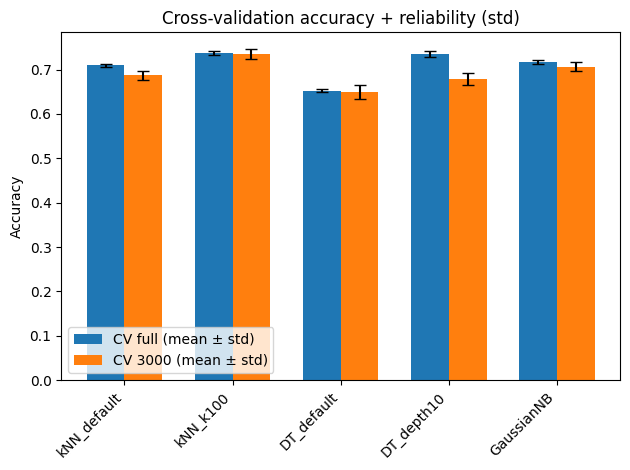

In [33]:
# --- 2) Plot: CV mean accuracy with reliability (std) as error bars ---
models = comparison_table.index.to_list()

cv_full_mean = comparison_table["CV_full_mean"].values
cv_full_std  = comparison_table["CV_full_std"].values

cv_3000_mean = comparison_table["CV_3000_mean"].values
cv_3000_std  = comparison_table["CV_3000_std"].values

x = np.arange(len(models))
w = 0.35

plt.figure()
plt.bar(x - w/2, cv_full_mean, width=w, yerr=cv_full_std, capsize=4, label="CV full (mean ± std)")
plt.bar(x + w/2, cv_3000_mean, width=w, yerr=cv_3000_std, capsize=4, label="CV 3000 (mean ± std)")
plt.xticks(x, models, rotation=45, ha="right")
plt.ylabel("Accuracy")
plt.title("Cross-validation accuracy + reliability (std)")
plt.legend()
plt.tight_layout()
plt.show()

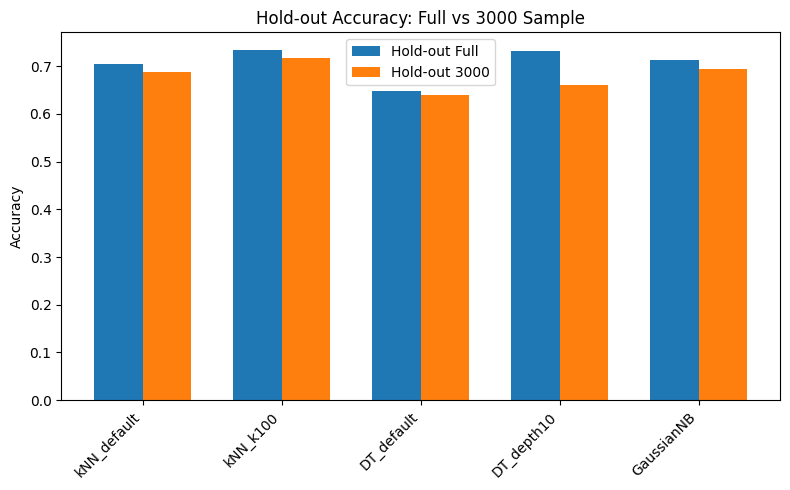

In [34]:
import matplotlib.pyplot as plt
import numpy as np

# беремо дані з comparison_table
models = comparison_table.index.tolist()
holdout_full = comparison_table["Holdout_full"].values
holdout_3000 = comparison_table["Holdout_3000"].values

x = np.arange(len(models))
width = 0.35

plt.figure(figsize=(8,5))

plt.bar(x - width/2, holdout_full, width, label="Hold-out Full")
plt.bar(x + width/2, holdout_3000, width, label="Hold-out 3000")

plt.xticks(x, models, rotation=45, ha='right')
plt.ylabel("Accuracy")
plt.title("Hold-out Accuracy: Full vs 3000 Sample")
plt.legend()

plt.tight_layout()
plt.show()

********************************************************************************